In [2]:
print(9)

9


In [6]:
# class for icd code hierarchial tree
class ICDcodeNode:
    def __init__(self, icd_code, description, children, parent):
        self.icd_code = icd_code
        self.description = description
        self.children  =  children
        self.parent = parent

    def get_children(self):
        return self.children
    
    def add_child(self, child):
        if child not in self.children:
            self.children.append(child)

    def get_parent(self):
        return self.parent
    
    def set_parent(self,parent):
        self.parent = parent

    def __repr__(self):
        return f'{self.icd_code} - {self.description} -  Children: {[x.icd_code for x in self.children]}'


In [ ]:

import pandas as pd
import faiss
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import pickle
import networkx as nx
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

# ===========================
# CONFIG
# ===========================
SAPBERT_MODEL = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
BILORD_MODEL = "abhinand/MedEmbed-large-v0.1"

SAPBERT_INDEX = r"C:\Users\UNegi\Documents\Project\makethon\index\icd10_faiss_sapbert_from_pubmedbert.index"
SAPBERT_META = r"C:\Users\UNegi\Documents\Project\makethon\index\icd10_metadata_sapbert_from_pubmedbert.xlsx"
BILORD_INDEX = r"C:\Users\UNegi\Documents\Project\makethon\index\icd10_faiss_medembed.index"
BILORD_META = r"C:\Users\UNegi\Documents\Project\makethon\index\icd10_metadata_medembed.xlsx"
ICD_GRAPH_PICKLE = r"C:\\Users\\UNegi\\Documents\\Project\\makethon\\icd_code_hierarchy.pkl"

# ===========================
# LOAD MODELS & INDEXES
# ===========================
sap_tokenizer = AutoTokenizer.from_pretrained(SAPBERT_MODEL)
sap_model = AutoModel.from_pretrained(SAPBERT_MODEL).to(DEVICE).eval()

bilord_tokenizer = AutoTokenizer.from_pretrained(BILORD_MODEL)
bilord_model = AutoModel.from_pretrained(BILORD_MODEL).to(DEVICE).eval()

sap_index = faiss.read_index(SAPBERT_INDEX)
bilord_index = faiss.read_index(BILORD_INDEX)

sap_meta_df = pd.read_excel(SAPBERT_META)
bilord_meta_df = pd.read_excel(BILORD_META)

sap_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in sap_meta_df.iterrows()}
bilord_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in bilord_meta_df.iterrows()}

# ===========================
# EMBEDDING FUNCTIONS
# ===========================
def mean_pooling(last_hidden_state, attention_mask):
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)

def embed_texts(texts, tokenizer, model):
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i:i+BATCH_SIZE]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
            out = model(**enc)
            emb = mean_pooling(out.last_hidden_state, enc["attention_mask"])
            emb = emb.cpu().numpy()
            all_embs.append(emb)
    embs = np.vstack(all_embs).astype("float32")
    embs /= np.linalg.norm(embs, axis=1, keepdims=True)  # L2 normalization
    return embs

# ===========================
# SEARCH FUNCTION
# ===========================
def search_model(query, index, tokenizer, model, metadata, top_k=200):
    q_emb = embed_texts([query], tokenizer, model)
    D, I = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(D[0], I[0]):
        meta = metadata[idx]
        results.append({"code": meta["code"], "description": meta["description"], "score": float(score), "id": idx})
    return results

# ===========================
# LOAD ICD GRAPH
# ===========================
with open(ICD_GRAPH_PICKLE, "rb") as f:
    node_dict = pickle.load(f)
root_node = node_dict['root']
graph = nx.Graph()

def build_networkx_graph(node):
    graph.add_node(node.icd_code, description=node.description)
    for child in node.get_children():
        graph.add_edge(node.icd_code, child.icd_code)
        build_networkx_graph(child)

build_networkx_graph(root_node)
print(f"Graph loaded: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

# ===========================
# LATE FUSION WITH BOOSTING
# ===========================
def late_fusion_with_graph_proximity(query, alpha=0.1, beta=0.9, gamma=0, overlap_bonus=0.1, top_k=200):
    sap_results = search_model(query, sap_index, sap_tokenizer, sap_model, sap_metadata, top_k)
    bilord_results = search_model(query, bilord_index, bilord_tokenizer, bilord_model, bilord_metadata, top_k)

    combined = {}
    for r in sap_results:
        combined[r["code"]] = alpha * r["score"]

    for r in bilord_results:
        if r["code"] in combined:
            combined[r["code"]] += beta * r["score"] + overlap_bonus  # extra boost for overlap
        else:
            combined[r["code"]] = beta * r["score"]

    ranked_initial = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    anchor_code = ranked_initial[0][0]

    # Graph-based boosting
    boosted_nodes = {}
    if anchor_code in graph:
        boosted_nodes[anchor_code] = gamma * 1.0
        for parent in graph.neighbors(anchor_code):
            boosted_nodes[parent] = gamma * 0.8
            for sib in graph.neighbors(parent):
                if sib != anchor_code:
                    boosted_nodes[sib] = gamma * 0.6
            for gp in graph.neighbors(parent):
                if gp != anchor_code and gp != parent:
                    boosted_nodes[gp] = gamma * 0.7
                    for block_child in graph.neighbors(gp):
                        if block_child != parent:
                            boosted_nodes[block_child] = gamma * 0.6

    for code, boost in boosted_nodes.items():
        if code in combined:
            combined[code] += boost

    # Normalize to 0–100 for display
    scores = list(combined.values())
    min_score, max_score = min(scores), max(scores)
    normalized_combined = {code: 100 * (score - min_score) / (max_score - min_score) for code, score in combined.items()}

    ranked_final = sorted(normalized_combined.items(), key=lambda x: x[1], reverse=True)

    formatted_results = []
    for code, score in ranked_final:
        description = sap_meta_df.loc[sap_meta_df["Code"] == code, "Description"].values
        if len(description) == 0:
            description = bilord_meta_df.loc[bilord_meta_df["Code"] == code, "Description"].values
        description = description[0] if len(description) > 0 else "Description not found"
        formatted_results.append({
            "ICD_Code": code.strip(),
            "Description": description,
            "Score (0-100)": round(score, 2)
        })

    return formatted_results, anchor_code, boosted_nodes

# ===========================
# VISUALIZATION
# ===========================
def visualize_boosted_graph(anchor_code, boosted_nodes):
    pos = nx.spring_layout(graph, seed=42)
    node_colors = []
    node_sizes = []
    for node in graph.nodes():
        if node == anchor_code:
            node_colors.append("red")
            node_sizes.append(900)
        elif node in boosted_nodes:
            node_colors.append("orange" if boosted_nodes[node] >= 0.7 else "yellow")
            node_sizes.append(700)
        else:
            node_colors.append("lightgray")
            node_sizes.append(400)
    plt.figure(figsize=(12, 8))
    nx.draw(graph, pos, with_labels=True, node_color=node_colors, node_size=node_sizes, font_size=8)
    plt.title(f"ICD Graph Boost Visualization (Anchor: {anchor_code})")
    plt.show()

# ===========================
# TEST PIPELINE
# ===========================
query = "heart attack"
final_results, anchor_code, boosted_nodes = late_fusion_with_graph_proximity(query)
print("Top 10 ICD codes after late fusion + hierarchy boost:")
for res in final_results[:30]:
    print(res)


In [1]:

import pandas as pd
import faiss
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import pickle
import networkx as nx
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

# ===========================
# CONFIG
# ===========================
SAPBERT_MODEL = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
MEDEMBED_MODEL = "abhinand/MedEmbed-large-v0.1"

SAPBERT_INDEX = r"C:\Users\UNegi\Documents\Project\makethon\index\icd10_faiss_sapbert_from_pubmedbert.index"
SAPBERT_META = r"C:\Users\UNegi\Documents\Project\makethon\index\icd10_metadata_sapbert_from_pubmedbert.xlsx"
MEDEMBED_INDEX = r"C:\Users\UNegi\Documents\Project\makethon\index\icd10_faiss_medembed.index"
MEDEMBED_META = r"C:\Users\UNegi\Documents\Project\makethon\index\icd10_metadata_medembed.xlsx"
ICD_GRAPH_PICKLE = r"C:\\Users\\UNegi\\Documents\\Project\\makethon\\icd_code_hierarchy.pkl"

# ===========================
# LOAD MODELS & INDEXES
# ===========================
sap_tokenizer = AutoTokenizer.from_pretrained(SAPBERT_MODEL)
sap_model = AutoModel.from_pretrained(SAPBERT_MODEL).to(DEVICE).eval()

medembed_tokenizer = AutoTokenizer.from_pretrained(MEDEMBED_MODEL)
medembed_model = AutoModel.from_pretrained(MEDEMBED_MODEL).to(DEVICE).eval()

sap_index = faiss.read_index(SAPBERT_INDEX)
medembed_index = faiss.read_index(MEDEMBED_INDEX)

sap_meta_df = pd.read_excel(SAPBERT_META)
medembed_meta_df = pd.read_excel(MEDEMBED_META)

sap_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in sap_meta_df.iterrows()}
medembed_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in medembed_meta_df.iterrows()}

# ===========================
# EMBEDDING FUNCTIONS
# ===========================
def mean_pooling(last_hidden_state, attention_mask):
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)

def embed_texts(texts, tokenizer, model):
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i:i+BATCH_SIZE]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
            out = model(**enc)
            emb = mean_pooling(out.last_hidden_state, enc["attention_mask"])
            emb = emb.cpu().numpy()
            all_embs.append(emb)
    embs = np.vstack(all_embs).astype("float32")
    embs /= np.linalg.norm(embs, axis=1, keepdims=True)  # L2 normalization
    return embs

# ===========================
# SEARCH FUNCTION
# ===========================
def search_model(query, index, tokenizer, model, metadata, top_k=200):
    q_emb = embed_texts([query], tokenizer, model)
    D, I = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(D[0], I[0]):
        meta = metadata[idx]
        results.append({"code": meta["code"], "description": meta["description"], "score": float(score), "id": idx})
    return results

def build_networkx_graph(root_node):
    graph = nx.DiGraph()  # Use directed graph for parent-child

    def add_nodes_edges(node):
        graph.add_node(node.icd_code, description=node.description)
        for child in node.get_children():
            graph.add_edge(node.icd_code, child.icd_code)  # parent -> child
            add_nodes_edges(child)

    add_nodes_edges(root_node)
    return graph


# ===========================
# LATE FUSION WITH BOOSTING
# ===========================
def late_fusion_with_graph_proximity(query, alpha=1, beta=0, gamma=0.3, overlap_bonus=0.1, top_k=200):
    sap_results = search_model(query, sap_index, sap_tokenizer, sap_model, sap_metadata, top_k)
    medembed_results = search_model(query, medembed_index, medembed_tokenizer, medembed_model, medembed_metadata, top_k)

    combined = {}
    for r in sap_results:
        combined[r["code"]] = alpha * r["score"]

    for r in medembed_results:
        if r["code"] in combined:
            combined[r["code"]] += beta * r["score"] + overlap_bonus  # extra boost for overlap
        else:
            combined[r["code"]] = beta * r["score"]

    ranked_initial = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    anchor_code = ranked_initial[0][0].strip()
    boosted_nodes = {}
    with open(ICD_GRAPH_PICKLE, "rb") as f:
        node_dict = pickle.load(f)
    root_node = node_dict['root']
    graph = build_networkx_graph(root_node)
    print(f"Graph loaded: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

    if anchor_code in graph:
        # Boost anchor
        boosted_nodes[anchor_code] = gamma * 1.0

        # Get parent
        parents = list(graph.predecessors(anchor_code))
        if parents:
            parent = parents[0]
            boosted_nodes[parent] = gamma * 0.8

            # Boost siblings (children of parent except anchor)
            siblings = [child for child in graph.successors(parent) if child != anchor_code]
            for sib in siblings:
                boosted_nodes[sib] = gamma * 0.6

            # Get grandparent
            grandparents = list(graph.predecessors(parent))
            if grandparents:
                grandparent = grandparents[0]
                boosted_nodes[grandparent] = gamma * 0.7

                # Boost children of grandparent (categories like I21, I22)
                category_nodes = list(graph.successors(grandparent))
                for cat in category_nodes:
                    if cat != parent:
                        boosted_nodes[cat] = gamma * 0.6

                    # Boost children of these categories
                    for cat_child in graph.successors(cat):
                        boosted_nodes[cat_child] = gamma * 0.5

    for code, boost in boosted_nodes.items():
        if code in combined:
            combined[code] += boost

    # Normalize to 0–100 for display
    scores = list(combined.values())
    min_score, max_score = min(scores), max(scores)
    normalized_combined = {code: 100 * (score - min_score) / (max_score - min_score) for code, score in combined.items()}

    ranked_final = sorted(normalized_combined.items(), key=lambda x: x[1], reverse=True)

    formatted_results = []
    for code, score in ranked_final:
        description = sap_meta_df.loc[sap_meta_df["Code"] == code, "Description"].values
        if len(description) == 0:
            description = medembed_meta_df.loc[medembed_meta_df["Code"] == code, "Description"].values
        description = description[0] if len(description) > 0 else "Description not found"
        formatted_results.append({
            "ICD_Code": code.strip(),
            "Description": description,
            "Score (0-100)": round(score, 2)
        })

    return formatted_results, anchor_code, boosted_nodes


# ===========================
# TEST PIPELINE
# ===========================
query = "congenital  Syphliitic corneal inflation "
final_results, anchor_code, boosted_nodes = late_fusion_with_graph_proximity(query)
print("Top 30 ICD codes after late fusion + hierarchy boost:")
print(type(anchor_code))
print(boosted_nodes)
for res in final_results[:30]:
    print(res)


c:\Users\UNegi\Documents\Project\makethon\.health\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [5]:
import pandas as pd

data = [
    {'ICD_Code': 'Z859', 'Description': 'Personal history of malignant neoplasm, unspecified', 'Score (0-100)': 100.0},
    {'ICD_Code': 'C801', 'Description': 'Malignant (primary) neoplasm, unspecified', 'Score (0-100)': 99.62}
]

df = pd.DataFrame(data)

print(df)
anchor_code

  ICD_Code                                        Description  Score (0-100)
0     Z859  Personal history of malignant neoplasm, unspec...         100.00
1     C801          Malignant (primary) neoplasm, unspecified          99.62


'Z859'

In [ ]:
with open(ICD_GRAPH_PICKLE, "rb") as f:
    node_dict = pickle.load(f)
root_node = node_dict['root']
graph = build_networkx_graph(root_node)
print(f"Graph loaded: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
def build_networkx_graph(root_node):
    graph = nx.DiGraph()  # Use directed graph for parent-child

    def add_nodes_edges(node):
        graph.add_node(node.icd_code, description=node.description)
        for child in node.get_children():
            graph.add_edge(node.icd_code, child.icd_code)  # parent -> child
            add_nodes_edges(child)

    add_nodes_edges(root_node)
    return graph
if anchor_code in graph:
    # Boost anchor
    boosted_nodes[anchor_code] = gamma * 1.0

    # Get parent
    parents = list(graph.predecessors(anchor_code))
    if parents:
        parent = parents[0]
        boosted_nodes[parent] = gamma * 0.8

        # Boost siblings (children of parent except anchor)
        siblings = [child for child in graph.successors(parent) if child != anchor_code]
        for sib in siblings:
            boosted_nodes[sib] = gamma * 0.6

        # Get grandparent
        grandparents = list(graph.predecessors(parent))
        if grandparents:
            grandparent = grandparents[0]
            boosted_nodes[grandparent] = gamma * 0.7

            # Boost children of grandparent (categories like I21, I22)
            category_nodes = list(graph.successors(grandparent))
            for cat in category_nodes:
                if cat != parent:
                    boosted_nodes[cat] = gamma * 0.6

                # Boost children of these categories
                for cat_child in graph.successors(cat):
                    boosted_nodes[cat_child] = gamma * 0.5

Built graph


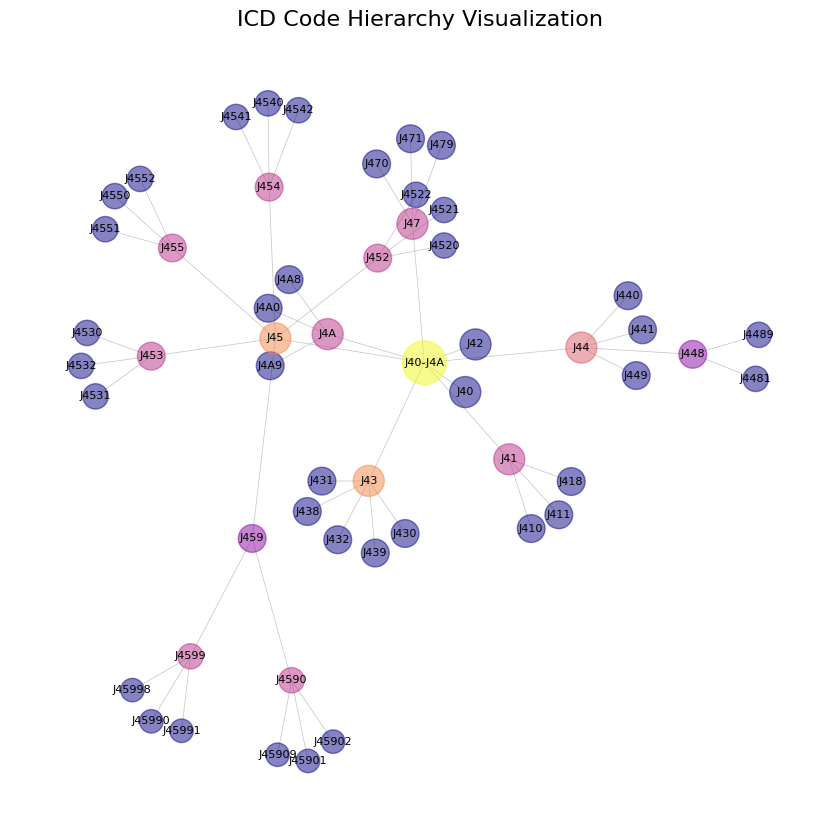

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
# class for icd code hierarchial tree
class ICDcodeNode:
    def __init__(self, icd_code, description, children, parent):
        self.icd_code = icd_code
        self.description = description
        self.children  =  children
        self.parent = parent

    def get_children(self):
        return self.children
    
    def add_child(self, child):
        if child not in self.children:
            self.children.append(child)

    def get_parent(self):
        return self.parent
    
    def set_parent(self,parent):
        self.parent = parent

    def __repr__(self):
        return f'{self.icd_code} - {self.description} -  Children: {[x.icd_code for x in self.children]}'

def build_networkx_graph(root_node):
    """Convert ICDcodeNode tree to NetworkX graph"""
    graph = nx.Graph()

    def add_nodes_edges(node):
        # Add node with its ICD code and description as attributes
        graph.add_node(node.icd_code, description=node.description)

        # Add edges for each child
        for child in node.get_children():
            graph.add_edge(node.icd_code, child.icd_code)
            add_nodes_edges(child)

    add_nodes_edges(root_node)
    return graph

def visualize_large_graph(graph):
    """Visualize NetworkX graph with matplotlib"""
    pos = nx.spring_layout(graph, k=0.1, iterations=100) #spacing between nodes

    plt.figure(figsize=(8.5, 8.5))

    # Draw edges
    nx.draw_networkx_edges(graph, pos, alpha=0.5, width=0.5, edge_color='#888')

    # Draw nodes
    node_sizes = []
    for node in graph.nodes():
        # Size inversely proportional to ICD code length (longer codes are lower in the hierarchy)
        code_length = len(node)
        if '-' in node: #(code is a section/chapter)
            code_length = 1
        node_sizes.append(1 / (code_length + 1) * 2000)  # Scale factor

    nx.draw_networkx_nodes(
        graph, pos, 
        node_size=node_sizes,
        node_color=[len(graph.edges(n)) for n in graph.nodes()],
        cmap=plt.cm.plasma, alpha=0.5
    )

    # Add labels to nodes (ICD codes)
    labels = {node: node for node in graph.nodes()}
    nx.draw_networkx_labels(graph, pos, labels, font_size=8)

    plt.title('ICD Code Hierarchy Visualization', fontsize=16)
    plt.axis('off') 
    plt.tight_layout()
    plt.show()

with open(ICD_GRAPH_PICKLE, "rb") as f:
    node_dict = pickle.load(f)
root_node = node_dict['J40-J4A']

# Convert to NetworkX graph and visualize
graph = build_networkx_graph(root_node)
print('Built graph')
visualize_large_graph(graph)

In [ ]:
ancestors = nx.ancestors(graph, "I219")

In [ ]:

parent = list(graph.predecessors("I21"))

In [ ]:

def build_networkx_graph(root_node):
    graph = nx.DiGraph()  # Use directed graph for parent-child

    def add_nodes_edges(node):
        graph.add_node(node.icd_code, description=node.description)
        for child in node.get_children():
            graph.add_edge(node.icd_code, child.icd_code)  # parent -> child
            add_nodes_edges(child)

    add_nodes_edges(root_node)
    return graph

graph = build_networkx_graph(node_dict['root'])
anchor_code = "I219"
gamma = 0.3
boosted_nodes = {}
if anchor_code in graph:
    boosted_nodes[anchor_code] = gamma * 1.0
    for parent in graph.neighbors(anchor_code):
        boosted_nodes[parent] = gamma * 0.8
        for sib in graph.neighbors(parent):
            if sib != anchor_code:
                boosted_nodes[sib] = gamma * 0.6
        for gp in graph.neighbors(parent):
            if gp != anchor_code and gp != parent:
                boosted_nodes[gp] = gamma * 0.7
                for block_child in graph.neighbors(gp):
                    if block_child != parent:
                        boosted_nodes[block_child] = gamma * 0.6

In [ ]:

graph = build_networkx_graph(node_dict['root'])

In [ ]:

parent = list(graph.predecessors("I219"))  # Example ICD code
print("Parent:", parent)


In [ ]:
parent = graph.neighbors("I219")

In [ ]:
parent
anchor_code = "I219"
gamma = 0.3

In [ ]:
boosted_nodes = {}
if anchor_code in graph:
    boosted_nodes[anchor_code] = gamma * 1.0
    for parent in graph.neighbors(anchor_code):
        boosted_nodes[parent] = gamma * 0.8
        for sib in graph.neighbors(parent):
            if sib != anchor_code:
                boosted_nodes[sib] = gamma * 0.6
        for gp in graph.neighbors(parent):
            if gp != anchor_code and gp != parent:
                boosted_nodes[gp] = gamma * 0.7
                for block_child in graph.neighbors(gp):
                    if block_child != parent:
                        boosted_nodes[block_child] = gamma * 0.6

In [ ]:

anchor_code = "I219"
gamma = 0.3
boosted_nodes = {}

if anchor_code in graph:
    # Boost anchor
    boosted_nodes[anchor_code] = gamma * 1.0

    # Get parent
    parents = list(graph.predecessors(anchor_code))
    if parents:
        parent = parents[0]
        boosted_nodes[parent] = gamma * 0.8

        # Boost siblings (children of parent except anchor)
        siblings = [child for child in graph.successors(parent) if child != anchor_code]
        for sib in siblings:
            boosted_nodes[sib] = gamma * 0.6

        # Get grandparent
        grandparents = list(graph.predecessors(parent))
        if grandparents:
            grandparent = grandparents[0]
            boosted_nodes[grandparent] = gamma * 0.7

            # Boost children of grandparent (categories like I21, I22)
            category_nodes = list(graph.successors(grandparent))
            for cat in category_nodes:
                if cat != parent:
                    boosted_nodes[cat] = gamma * 0.6

                # Boost children of these categories
                for cat_child in graph.successors(cat):
                    boosted_nodes[cat_child] = gamma * 0.5


In [ ]:
boosted_nodes

In [ ]:
for parent in graph.neighbors(anchor_code):
    print(parent)

In [ ]:

ancestors = nx.ancestors(graph, "I219")
print("All ancestors:", ancestors)
